### Conceitos Básicos de Estatística (Tendência Central e Variância)

In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df = pd.read_csv("state.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'state.csv'

In [ ]:
df.info()

In [ ]:
# Média Simples
df.Population.mean()

In [ ]:
# Mediana
df.Population.median()

In [ ]:
from scipy.stats import trim_mean

#Média trimmed

trim_mean(df.Population,0.1) # I dropped out the 10% extreme values

In [ ]:
# Média Ponderada
df.Population = df.Population.astype(float)
np.average(df["Murder.Rate"],weights=df["Population"])

In [ ]:
# Mediana Ponderada
!pip install weightedstats -q

import weightedstats as ws
df.Population = df.Population.astype(float)
ws.weighted_median(df["Murder.Rate"],weights=df["Population"])

In [ ]:
# Desvio padrão (this one is higher than others because it's sensive to outliers)
df.Population.std()

In [ ]:
# IQR (Intervalo interquartil)
df.Population.quantile(0.75) - df.Population.quantile(0.25)

In [ ]:
# Mean Absolute Deviation
np.mean(np.abs(df.Population - df.Population.mean()))

In [ ]:
# Median Absolute deviation
stats.median_abs_deviation(df.Population)

In [ ]:
# Quantiles
df["Murder.Rate"].quantile([0.25,0.5,0.75,0.95])

In [ ]:
# Box plot
ax = (df['Population']/1_000_000).plot.box()
ax.set_ylabel('Population (millions)');

In [ ]:
# Frequency Tables and histograms
binnedPopulation = pd.cut(df['Population'], 10)
binnedPopulation.value_counts()

In [ ]:
ax = (df['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')

In [ ]:
# Density plot
ax = df['Murder.Rate'].plot.hist(density=True, xlim=[0,12], bins=range(1,12))
df['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')

### SMP 500

In [ ]:
df2 = pd.read_csv("sp500_data.csv.gz", compression="gzip")
df2.head(3)

In [ ]:
bdf2['Date'] = pd.to_datetime(df2['Unnamed: 0'])
df2_filtered = df2[df2['Date'] > '2012-07-01']

# from df2 to demonstrate the correlation heatmap.
# This assumes the user wants to see a correlation heatmap of some stock returns after a certain date.
selected_symbols = ['MSFT', 'IBM', 'AMGN', 'GILD', 'CTSH']

etfs_or_selected_stocks = df2_filtered[selected_symbols]

sns.heatmap(etfs_or_selected_stocks.corr(), vmin=-1, vmax=1,
            cmap=sns.diverging_palette(20, 220, as_cmap=True), annot=True)

### Violin plot and Boxplot (numerical vs categorical)

In [ ]:
airline_df = pd.read_csv("airline_stats.csv")
airline_df.head()

In [ ]:
# Create boxplot with better styling
fig, ax = plt.subplots(figsize=(12, 6))
airline_df.boxplot(
    by='airline',
    column='pct_carrier_delay',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
)
# Clean up labels and title
ax.set_xlabel('Airline', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily % of Delayed Flights', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Carrier Delays by Airline', fontsize=14, fontweight='bold', pad=20)
plt.suptitle('')  # Remove the default pandas title

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

# Add grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with appropriate size
fig, ax = plt.subplots(figsize=(12, 6))

# Create violin plot with better styling
sns.violinplot(
    data=airline_df,
    x='airline',
    y='pct_carrier_delay',
    ax=ax,
    inner='quartile',
    color='lightblue',
    alpha=0.8,
    linewidth=1.5
)

# Enhance labels and title
ax.set_xlabel('Airline', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily % of Delayed Flights', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Carrier Delays by Airline', fontsize=14, fontweight='bold', pad=20)

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

# Add grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

#Optional: Add median line across all violins for comparison
medians = airline_df.groupby('airline')['pct_carrier_delay'].median()
ax.hlines(medians.mean(), -0.5, len(medians)-0.5, colors='red', linestyles='dashed', alpha=0.5, label='Overall Median')

plt.tight_layout()
plt.show()

### Hexagonal Binning and Cotour Plots (numerical x numerical)

In [ ]:
tax_df = pd.read_csv("kc_tax.csv.gz", compression="gzip")
tax_df.head()


,TaxAssessedValue,SqFtTotLiving,ZipCode
0,NaN,1730,98117.0
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0


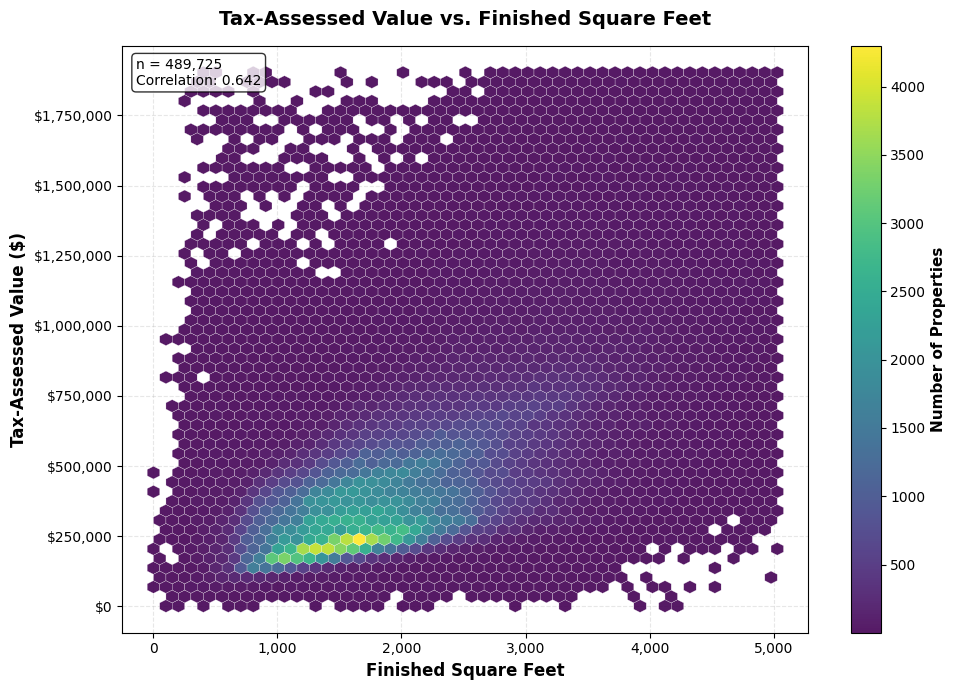

In [ ]:
# Filter out extreme outliers for better visualization
# Using 99th percentile to focus on the bulk of the data
tax_df_filtered = tax_df[
    (tax_df['SqFtTotLiving'] < tax_df['SqFtTotLiving'].quantile(0.99)) &
    (tax_df['TaxAssessedValue'] < tax_df['TaxAssessedValue'].quantile(0.99))
]

# Create figure with better control
fig, ax = plt.subplots(figsize=(10, 7))

# Create hexagonal binning plot with enhanced aesthetics
hexbin = ax.hexbin(
    tax_df_filtered['SqFtTotLiving'],
    tax_df_filtered['TaxAssessedValue'],
    gridsize=50,
    cmap='viridis',
    mincnt=1,  # Only show hexagons with at least 1 data point
    edgecolors='white',
    linewidths=0.2,
    alpha=0.9
)

# Add colorbar with label
cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Number of Properties', fontsize=11, fontweight='bold')

# Enhanced labels and title
ax.set_title('Tax-Assessed Value vs. Finished Square Feet',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Finished Square Feet', fontsize=12, fontweight='bold')
ax.set_ylabel('Tax-Assessed Value ($)', fontsize=12, fontweight='bold')

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Format x-axis with thousands separator
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add grid for easier reading
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Add statistics annotation
correlation = tax_df_filtered[['SqFtTotLiving', 'TaxAssessedValue']].corr().iloc[0, 1]
n_properties = len(tax_df_filtered)
ax.text(0.02, 0.98,
        f'n = {n_properties:,}\nCorrelation: {correlation:.3f}',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

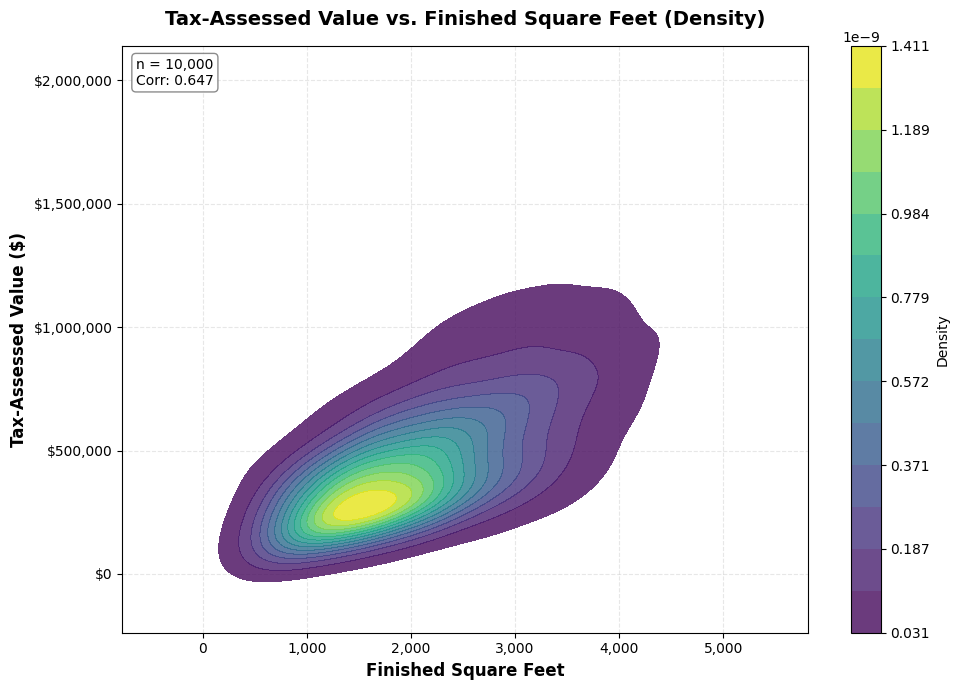

In [ ]:
# Filter outliers (cached computation)
q99_sqft = tax_df['SqFtTotLiving'].quantile(0.99)
q99_tax = tax_df['TaxAssessedValue'].quantile(0.99)
tax_df_filtered = tax_df[
    (tax_df['SqFtTotLiving'] < q99_sqft) &
    (tax_df['TaxAssessedValue'] < q99_tax)
]

# Sample data if dataset is very large (speeds up KDE calculation)
if len(tax_df_filtered) > 10000:
    tax_df_filtered = tax_df_filtered.sample(10000, random_state=42)

# Pre-calculate correlation
correlation = tax_df_filtered['SqFtTotLiving'].corr(tax_df_filtered['TaxAssessedValue'])
n_properties = len(tax_df_filtered)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# KDE plot with optimized settings
sns.kdeplot(
    data=tax_df_filtered,
    x='SqFtTotLiving',
    y='TaxAssessedValue',
    ax=ax,
    cmap='viridis',
    fill=True,
    levels=15,  # Reduced from 20 for faster rendering
    thresh=0.05,
    alpha=0.8,
    cbar=True,
    cbar_kws={'label': 'Density'},
    bw_adjust=1.5
)

# Labels and title
ax.set_title('Tax-Assessed Value vs. Finished Square Feet (Density)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Finished Square Feet', fontsize=12, fontweight='bold')
ax.set_ylabel('Tax-Assessed Value ($)', fontsize=12, fontweight='bold')

# Format axes
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Grid
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Statistics box
ax.text(0.02, 0.98,
        f'n = {n_properties:,}\nCorr: {correlation:.3f}',
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

### Poisson Distribution

In [2]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Ex: A distribution of calls around 100 minutes with mean 2
stats.poisson.rvs(2, size=100)

array([0, 3, 2, 2, 3, 1, 2, 2, 1, 4, 2, 4, 0, 1, 0, 1, 1, 2, 1, 4, 3, 1,
       2, 1, 4, 3, 4, 1, 3, 2, 1, 3, 2, 5, 2, 1, 0, 0, 3, 2, 1, 1, 3, 3,
       3, 0, 2, 3, 2, 4, 1, 3, 3, 3, 3, 3, 3, 1, 5, 2, 1, 1, 4, 1, 1, 2,
       2, 1, 3, 0, 2, 5, 1, 0, 2, 3, 1, 2, 0, 0, 0, 2, 4, 1, 2, 2, 3, 2,
       1, 0, 1, 6, 3, 5, 2, 1, 3, 3, 0, 2])

### Exponential Distribution
To calculate the mean of events in a periode of time with a rate (lambda)

In [3]:
# Simulate 100 intervals, in minutes, between services calls, where the average rate of incoming
# calls is 0.2 per minutes
stats.expon.rvs(scale=0.2, size=100)

array([0.08038594, 0.012303  , 0.0115674 , 0.10353876, 0.05877822,
       0.2796514 , 0.42691357, 0.07261844, 0.0213687 , 0.20095528,
       0.09922173, 0.47987267, 0.47787903, 0.01353629, 0.13672537,
       0.00856059, 0.49231867, 0.17034328, 0.05896872, 0.37427208,
       0.20162054, 0.18594585, 0.34305323, 0.03138597, 0.26395989,
       0.03779514, 0.05764554, 0.16829834, 0.03213117, 0.0097924 ,
       0.07541957, 0.0702612 , 0.08582234, 0.25565902, 0.23529856,
       0.06474886, 0.00444994, 0.56729871, 0.03006276, 0.08428403,
       0.41370879, 0.0434617 , 0.02775541, 0.03937669, 0.73720098,
       0.10030634, 0.02274863, 0.04222313, 0.07058901, 0.07483627,
       0.12508579, 0.1237764 , 0.01587814, 0.06729401, 0.07695202,
       0.21434335, 0.08452031, 0.13817838, 0.10918071, 0.02352566,
       0.8224218 , 0.17697818, 0.25572172, 0.03612452, 0.17209375,
       0.06777491, 0.01733673, 0.15727589, 0.01573413, 0.1640172 ,
       0.10638606, 0.03162799, 0.05347955, 0.10219218, 0.09670

### Weibull Distribution
 A changing event rate over time (e.g., an increasing probability of device failure)
can be modeled with the Weibull distribution.

In [4]:
# the following code would generate 100 random numbers (lifetimes) from a Wei‐
# bull distribution with shape of 1.5 and characteristic life of 5,000:

stats.weibull_min.rvs(1.5, scale=5000, size=100)

array([ 7619.51432729,  2512.06582034,  1933.06022864,  4096.95434795,
        1154.36475628,  2116.50029575,  1820.70107118,  7874.37534874,
        5498.24468811,  6769.33007058,  3479.90155906,  3441.49469522,
        5300.82868937, 12085.01063104,  9340.66512035,  2195.990903  ,
        2392.8651752 ,   307.4460173 ,  3238.6143751 ,  4315.65791481,
        6174.87122404,  6229.50248256,  1443.96176646,  7663.53566603,
        1727.70127436,   920.84273987,  4942.57199937,  1719.00095344,
        8144.12735236,  2774.99392189,  2405.69032873,  2698.9752315 ,
         489.89120185,  4143.04482355,  2988.35574317,  2067.66486249,
        6428.74496551,  6400.34806805,  4472.13822539,  2199.56725182,
        3721.36707654,  7442.09903083, 10271.88637323,  5676.38218709,
        2883.50163343,   712.02688876,  2783.5574039 ,  4233.35676333,
        7612.66431097,  7044.25408905,  2952.29299216,  4750.49051764,
       16174.10651851,  4590.52031117,  3644.71385491,  3050.32859132,
      